In [2]:
import numpy as np
import matplotlib.pyplot as plt

from field_lines import PeriodicInterpolator, integrate_lines, unwrap_lines, plot_field_lines
from generate_kolmogorov import get_field_cube, set_cubes

## Field generation

In [3]:
L = 300  # [pc], half-size
n_side = 256
dx = 2*L/n_side # [pc], cell size
k_min = 2*np.pi / (2*L)  # [pc-1], injection scale
print(f"Each cell is a cube with size dx = {dx:.2f} pc")
print(f"Injection scale (2pi/k_min) is {2*np.pi/k_min:.2f} pc")

r_cube, k_cube = set_cubes(n_side, L)

Each cell is a cube with size dx = 2.34 pc
Injection scale (2pi/k_min) is 600.00 pc


In [4]:
b_cube = get_field_cube(n_side, L, power_index=11/3, k_min=k_min)  # normalized isotropic field

### Add the regular component

$$ \mathbf{B} = \dfrac{\mathbf{B}_0 + \eta\,\mathbf{\delta B}}{\sqrt{1 + \eta^2}} = \dfrac{1}{\sqrt{1 + \eta^2}}\mathbf{B}_0 + \dfrac{\eta}{\sqrt{1 + \eta^2}}\mathbf{\delta B}, $$

In [5]:
eta = 1.0

b0 = 1 / np.sqrt(1 + eta**2)

b_turb = eta / np.sqrt(1 + eta**2) * b_cube

b_cube_10 = b_turb
b_cube_10[2] += b0

### Check the spectrum (Fourier transform)

In [6]:
b_cube_k = np.fft.rfftn(b_cube_10, norm='forward')

In [7]:
bk2 = np.sum(np.abs(b_cube_k)**2, axis=0)
k_norm = np.sum(k_cube**2, axis=0)**0.5

In [8]:
min_k = k_norm[k_norm>0].min()

In [9]:
from scipy.stats import binned_statistic

bins = np.linspace(min_k, k_norm.max(), 200)

power, edges, _ = binned_statistic(
    k_norm.ravel(),
    bk2.ravel(),
    statistic="sum",
    bins=bins,
)

k_centers = 0.5 * (edges[:-1] + edges[1:])

In [10]:
k_values = np.unique(k_norm)
k_values = k_values[k_values > 0]

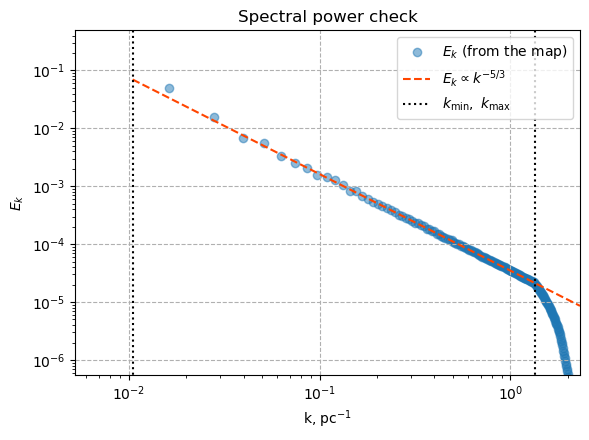

In [11]:
plt.figure(figsize=(6, 4.5))
plt.title("Spectral power check")

plt.scatter(k_centers, power, label=r'$E_k$ (from the map)', alpha=.5)
plt.loglog(k_values, 3.5e-5 * (k_values)**(-5/3), linestyle='dashed', label=r'$E_k\propto k^{-5/3}$', color='orangered')

plt.vlines([k_min, k_cube.max()], 1.1*min(power), 10*max(power), color='black', label=r'$k_\mathrm{min},~k_\mathrm{max}$', linestyles='dotted')

plt.xlabel(r'k, $\mathrm{pc}^{-1}$')
plt.xlim(0.5 * min_k, k_norm.max())

plt.ylabel(r'$E_k$')
plt.ylim(1e4*min(power), 10*max(power))

plt.legend(loc=1)

plt.grid(linestyle='dashed')

plt.tight_layout()
plt.show()

## Field lines

In [12]:
periodic_interpolator = PeriodicInterpolator(r_cube, b_cube_10)

In [13]:
M = 100
ds = dx / 5
n_steps = int(2 * L / ds)  # n_steps

# calculate field lines
lines = integrate_lines(periodic_interpolator, M, n_steps, ds)

# calculate magnetic fields along the line
fields = np.zeros([2*n_steps + 1, M, 3])
for i in range(M):
    fields[:, i, :] = periodic_interpolator(lines[:, i])

# now shift the lines to 0
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)

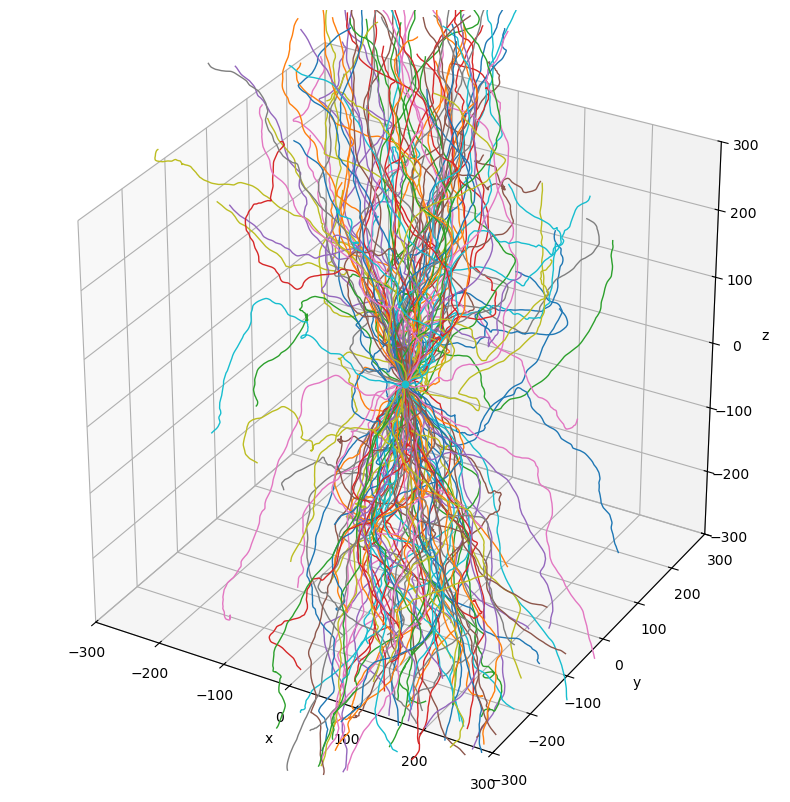

In [14]:
plot_field_lines(
    lines_from_zero,
    n_lines=M,
    box_size=L
)
plt.tight_layout()
plt.show()

### **MF strength distribution** in space and along the MF line

**Relativistic magnetic moment conservation:**

$$ \mu_r = \dfrac{m\gamma^2v_\perp^2}{2B};\quad \dfrac{d\mu_r}{dt} = 0$$

*! it differs from a non-relativistic version $\mu=K_\perp/2B$ !*

**Energy conservation:**

$$ E = \gamma mc^2 = \sqrt{(pc)^2 + (mc^2)^2}$$

In the high-energy limit,

$$ E^2 = (pc)^2 = (\gamma m vc)^2 = \gamma^2 m^2 c^2 (v_\parallel^2 + v_\perp^2) = \gamma^2m^2c^4\cos^2\alpha + 2B\mu_r mc^2 $$
$$ \sin^2\alpha = \dfrac{2B\mu_r mc^2}{E^2} $$

In [15]:
from scipy.stats import norm

#### Analytical expression in 3D space

How is $B$ supposed to be distributed?

$$ \mathbf{B} = \dfrac{\mathbf{B}_0 + \eta\,\mathbf{\delta B}}{\sqrt{1 + \eta^2}} = \dfrac{1}{\sqrt{1 + \eta^2}}\mathbf{B}_0 + \dfrac{\eta}{\sqrt{1 + \eta^2}}\mathbf{\delta B}, $$

As $\mathbf{\delta B}\sim\mathcal{N}(\vec{0}, I_3/3),$ the total field $\mathbf{B}\sim\mathcal{N}\left(\dfrac{\mathbf{B}_0}{\sqrt{1 + \eta^2}}, \dfrac{\eta I_3}{3\sqrt{1+\eta^2}}\right)$.

This means that $B\sim\text{Noncentral}~\chi_3$ or **noncentral Maxwell distribution**.

In [16]:
mod_b_lines = (np.sum(fields**2, axis=-1))**(1/2)
mf_values = np.linspace(0, 2.5, 200)

ncol = mod_b_lines.shape[1]
cmap = plt.get_cmap('rainbow', lut=ncol)

In [17]:
from scipy.stats import ncx2

sigma = 1 / np.sqrt(3)
sigma_ef = sigma * eta / np.sqrt(1 + eta**2)

lam = (b0 / sigma_ef)**2

pdf = 2 * mf_values * ncx2(nc=lam, scale=sigma_ef**2, df=3).pdf(mf_values**2)

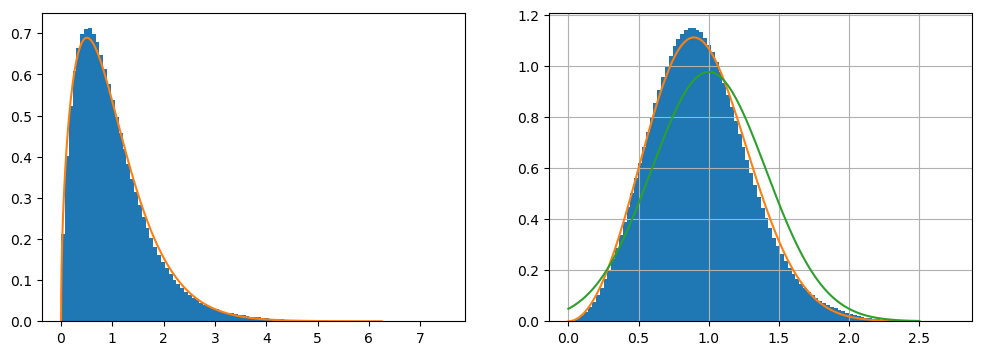

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.hist(np.sum(b_cube_10**2, axis=0).ravel(), density=True, bins=100)
plt.plot(mf_values**2, ncx2(nc=lam, scale=sigma_ef**2, df=3).pdf(mf_values**2))

plt.subplot(122)
plt.hist(np.sqrt(np.sum(b_cube_10**2, axis=0).ravel()), density=True, bins=100)
plt.plot(mf_values, pdf)
plt.plot(mf_values, norm(loc=1, scale=sigma_ef).pdf(mf_values))
plt.grid()

plt.show()

#### Distribution along the line

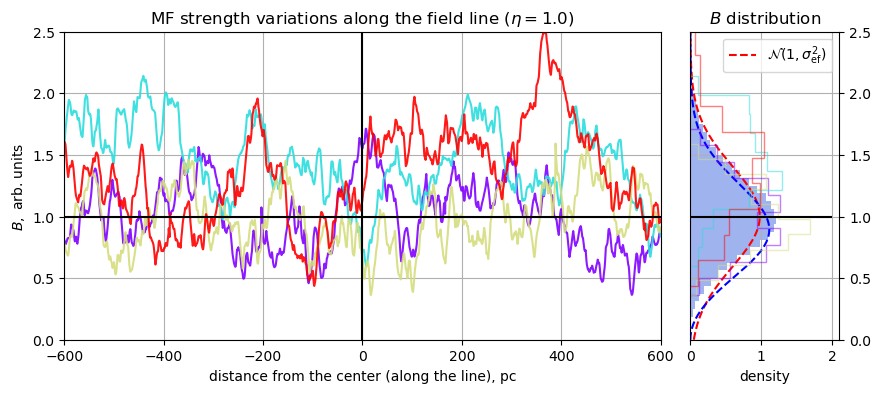

In [19]:

fig = plt.figure(figsize=(10, 4))
gs = plt.GridSpec(1, 2, fig, width_ratios=[4, 1], wspace=0.08)

ax = plt.subplot(gs[0, 0])
ax.set_title(r"MF strength variations along the field line ($\eta = $"f"{eta:.1f})")

for i in range(0, ncol, 33):
    ax.plot(np.arange(-n_steps, n_steps+1, 1) * ds, mod_b_lines[:, i], alpha=0.9, color=cmap(i/ncol))
    
ax.hlines([1.0], -ds*n_steps, ds*n_steps, color='black')
ax.vlines([0.0], mf_values[0], mf_values[-1], color='black')
    
ax.set_xlabel('distance from the center (along the line), pc')
ax.set_xlim(-ds*n_steps, ds*n_steps)
ax.set_ylabel(r"$B,$ arb. units")
ax.set_ylim(mf_values[0], mf_values[-1])
ax.grid()

# MF distribution
ax2 = plt.subplot(gs[0, 1])
ax2.set_title(r"$B$ distribution")
ax2.hist(mod_b_lines.ravel(), range=[mf_values[0], mf_values[-1]], bins=40,
         orientation='horizontal', density=True,
         alpha=0.5, color='royalblue')

ax2.plot(norm(loc=1, scale=sigma_ef).pdf(mf_values), mf_values, color='red', linestyle='dashed',
         label=r'$\mathcal{N}(1, \sigma_\mathrm{ef}^2)$')
ax2.plot(pdf, mf_values, color='blue', linestyle='dashed')

for i in range(0, ncol, 33):
    ax2.hist(mod_b_lines[:, i], alpha=0.5, color=cmap(i/ncol), histtype='step',
             orientation='horizontal', density=True)

ax2.hlines([1.0], 0, 2.0, color='black')

ax2.set_xlabel('density')
ax2.set_ylim(mf_values[0], mf_values[-1])
ax2.yaxis.tick_right()

ax2.legend(loc=1)

ax2.grid()

plt.show()

#### Power-spectrum along the line

In [20]:
k_s = 2 * np.pi * np.fft.rfftfreq(mod_b_lines.shape[0], d=ds)
mod_b_k = np.fft.rfft(mod_b_lines, axis=0, norm='forward')

In [21]:
print(f"Coordinate space: {mod_b_lines.shape}")
print(f"Momentum space: {mod_b_k.shape}")

Coordinate space: (2561, 100)
Momentum space: (1281, 100)


In [22]:
print(k_s)
print(2*np.pi/(2*n_steps*ds))

[0.00000000e+00 5.23394325e-03 1.04678865e-02 ... 6.68897947e+00
 6.69421341e+00 6.69944736e+00]
0.005235987755982988


In [23]:
2*np.pi / (0.1)

62.83185307179586

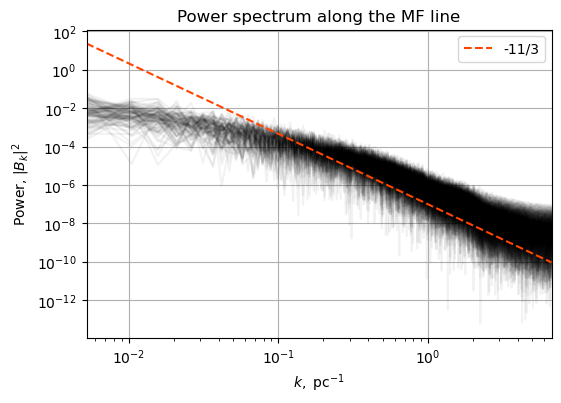

In [24]:
plt.figure(figsize=(6, 4))

plt.title("Power spectrum along the MF line")

plt.plot(k_s[k_s>0], np.abs(mod_b_k[k_s>0])**2, color='black', alpha=.05)
plt.plot(k_s[k_s>0], 1e-7 * k_s[k_s>0]**(-11/3), color='orangered', linestyle='dashed', label="-11/3")

plt.xscale('log')
plt.xlabel(r'$k,~\mathrm{pc}^{-1}$')
plt.xlim(2*np.pi/(2 * n_steps * ds), 2*np.pi/(2*ds))

plt.yscale('log')
plt.ylabel(r'Power, $|B_k|^2$')

plt.grid()
plt.legend(loc=1)

plt.show()

#### Typical magnetic field variation scale along the line

For this line, one can compute the average magnetic field variation scale $L_B \sim \dfrac{B}{\delta B / \delta s}$

In [25]:
grad_mod_b = (mod_b_lines[1:] - mod_b_lines[:-1]) / ds

b_avg = 0.5 * (mod_b_lines[1:] + mod_b_lines[:-1])

l_b = np.abs(b_avg / grad_mod_b).ravel()

l_b = l_b[l_b < 600]  # can't be > 600 pc

mean_l_b = np.average(l_b)

print(f"Average MF scale: {mean_l_b:.0f} pc")
print(f"Corresponding wavenumber {2*np.pi / mean_l_b:.3f} pc-1")

Average MF scale: 81 pc
Corresponding wavenumber 0.077 pc-1


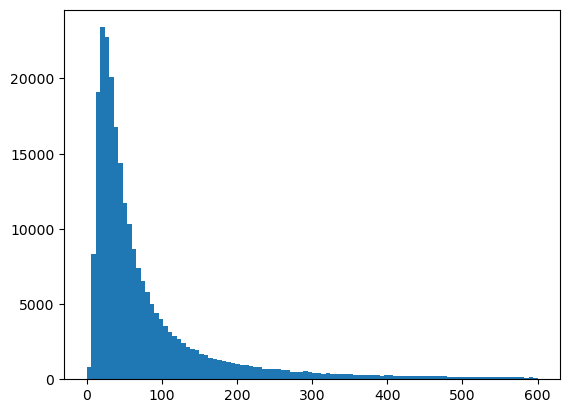

In [26]:
plt.hist(l_b, bins=100, range=(0, 600))
plt.show()

### Filtering

In [27]:
from scipy.ndimage import gaussian_filter1d

sigma = 300  # [pc], smoothing scale
lines_large = gaussian_filter1d(lines_from_zero, sigma=sigma, axis=0)

lines_large -= lines_large[n_steps, ...]

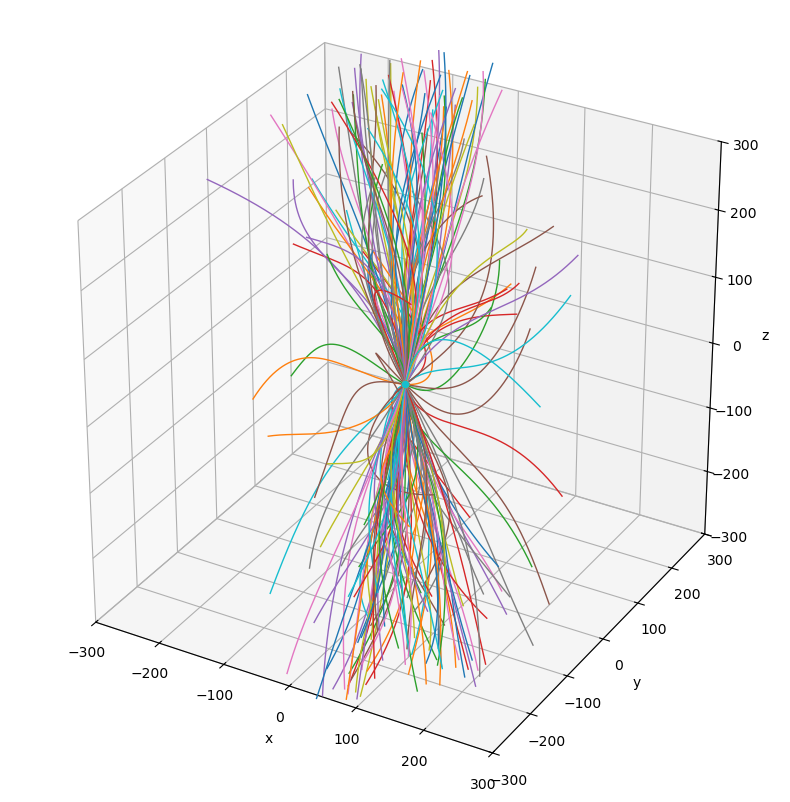

In [28]:
plot_field_lines(
    lines_large,
    n_lines=M,
    box_size=L
)
plt.tight_layout()
plt.show()

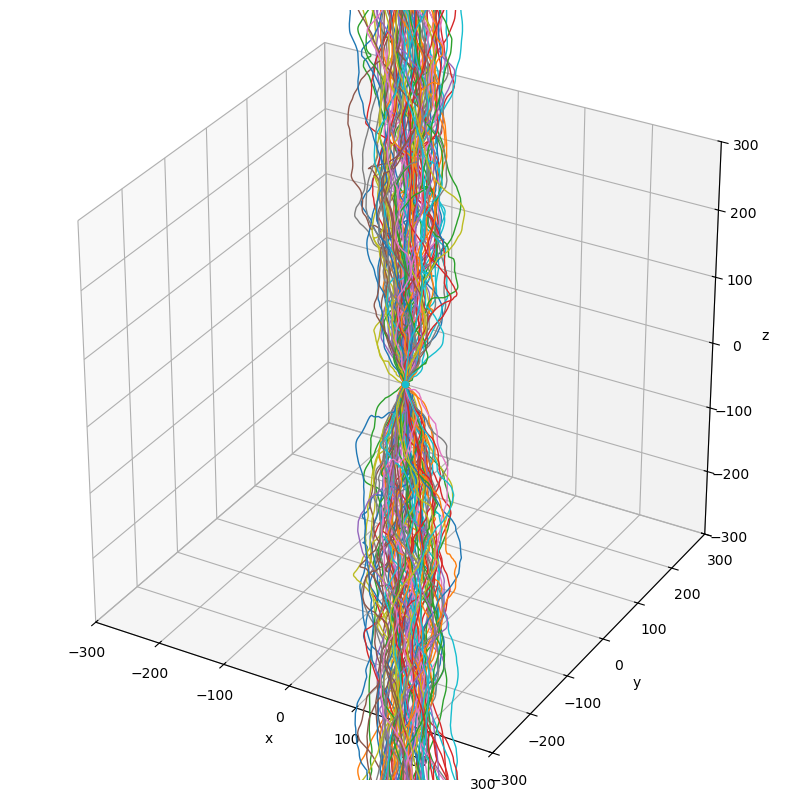

In [29]:
zero_vector = np.zeros_like(lines_large)

zero_vector[:, :, 2] =  (np.arange(-n_steps, n_steps+1, 1) * ds)[:, None]

plot_field_lines(
    (lines_from_zero - lines_large) + zero_vector,
    n_lines=M,
    box_size=L
)

# plot_field_lines(
#     lines_large,
#     n_lines=M,
#     box_size=L
# )
plt.tight_layout()
plt.show()

In [30]:
lines_from_zero.shape

(2561, 100, 3)

In [43]:
rho = lines_from_zero / np.linalg.norm(lines_from_zero, axis=-1, keepdims=True)
rho.shape

/tmp/ipykernel_16039/3722951336.py:1: RuntimeWarning: invalid value encountered in divide
  rho = lines_from_zero / np.linalg.norm(lines_from_zero, axis=-1, keepdims=True)


(2561, 100, 3)

## Observer view

Let observer direction be $\hat{n} = (\sin\phi, 0, \cos\phi)$.
In this case, we have to project the MF line onto the surface $\sigma: \vec{r}\cdot\hat{n} = 0.$

Projected vector is given by $\vec{r}_\sigma = \vec{r} - \hat{n}(\vec{r}\cdot\hat{n}) $

In [167]:
phi = np.linspace(0, 2 * np.pi, 36, endpoint=False)

n_vectors = np.array([np.sin(phi), np.zeros_like(phi), np.cos(phi)]).T
n_vectors.shape

(36, 3)

In [168]:
r_sigma = lines_from_zero[..., None, :]- n_vectors[None, None, ...] * np.sum(lines_from_zero[..., None, :] * n_vectors[None, None, ...], axis=-1, keepdims=True)

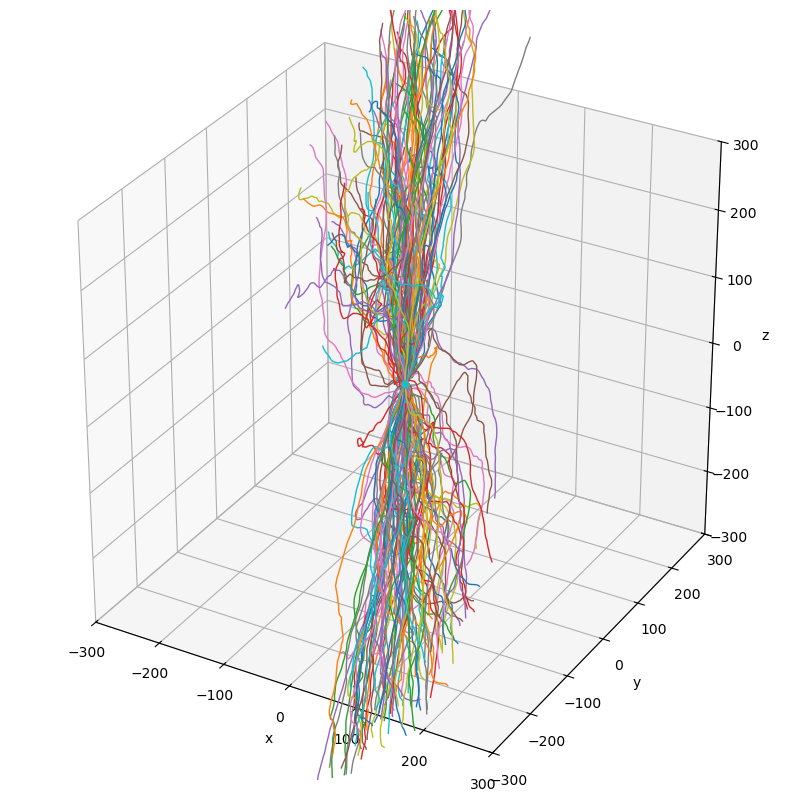

In [169]:
plot_field_lines(
    r_sigma[..., 9, :],
    n_lines=M,
    box_size=L
)

plt.tight_layout()
plt.show()

In [170]:
# create rotation matrix such that R n = z

In [177]:
ez = np.array([0, 0, 1]).T
a_nn = np.cross(n_vectors, ez)
a = a_nn / np.linalg.norm(a_nn, axis=-1, keepdims=True)  # axis of rotation

theta = np.arccos(n_vectors @ ez)  # rotation angle

rotated = r_sigma * np.cos(theta)[None, None, :, None] \
    + np.cross(a, r_sigma) * np.sin(theta)[None, None, :, None] \
    + a[None, None, ...] * np.sum(a[None, None, ...] * r_sigma, axis=-1, keepdims=True) * (1 - np.cos(theta))[None, None, :, None]

/tmp/ipykernel_16039/3535557393.py:3: RuntimeWarning: invalid value encountered in divide
  a = a_nn / np.linalg.norm(a_nn, axis=-1, keepdims=True)  # axis of rotation


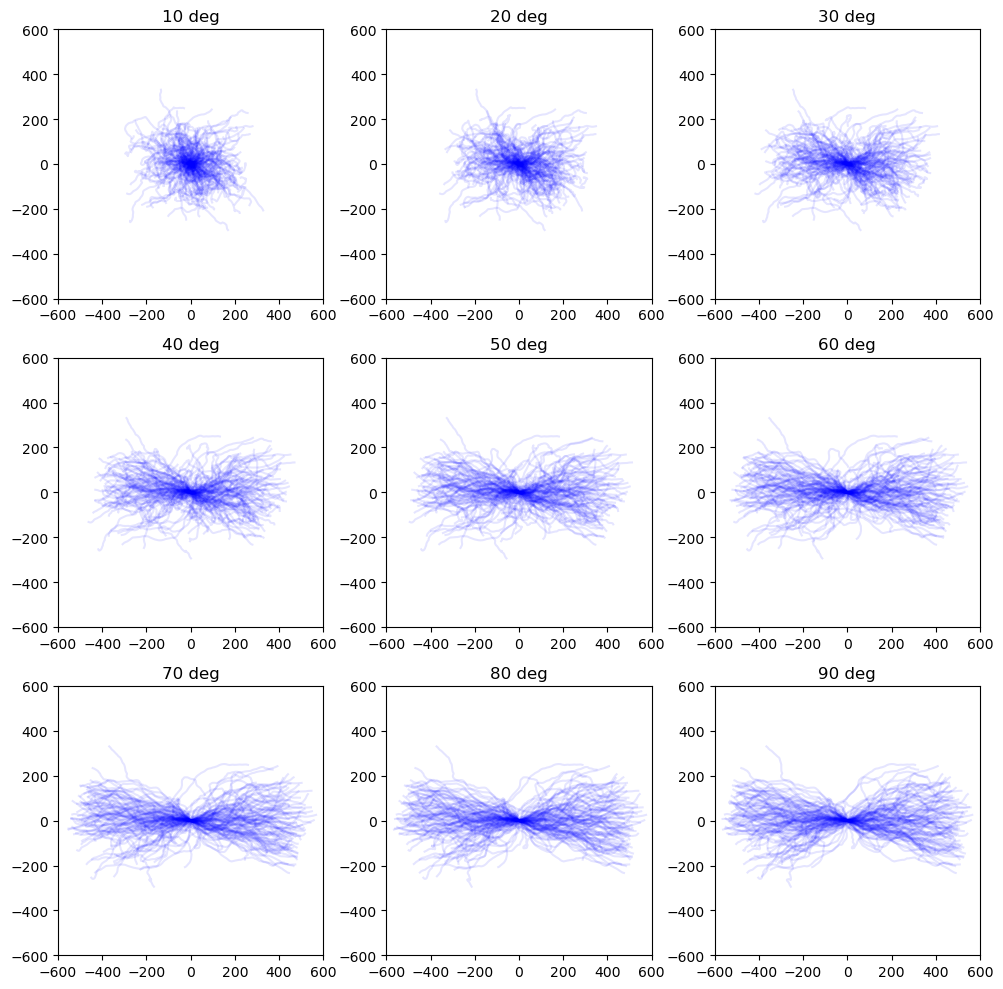

In [191]:
plt.figure(figsize=(10, 10))

for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.title(f"{np.rad2deg(phi[i]):.0f} deg")
    plt.xlim(-2*L, 2*L)
    plt.ylim(-2*L, 2*L)
    for m in range(0, M):
        x, y = rotated[::10, m, i, 0], rotated[::10, m, i, 1]
        plt.plot(x, y, color='blue', alpha=.1)

plt.tight_layout()
plt.show()